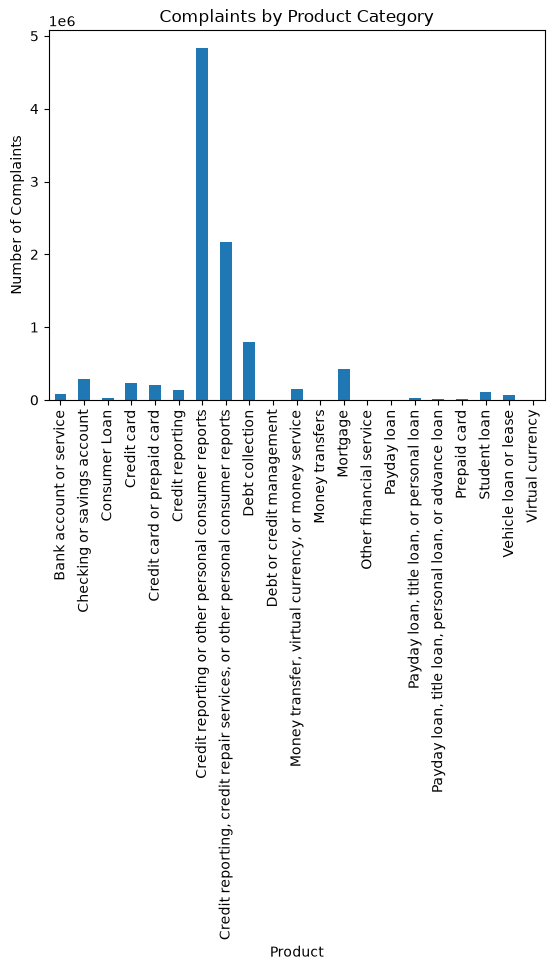

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Update the column name here
product_col = 'Product' 
file_path = '../data/complaints.csv'
chunk_size = 50000
product_counts = pd.Series(dtype=int)

# Process in chunks to count products safely
for chunk in pd.read_csv(file_path, chunksize=chunk_size, usecols=[product_col]):
    product_counts = product_counts.add(chunk[product_col].value_counts(), fill_value=0)

# Visualize distribution
product_counts.plot(kind='bar')
plt.title("Complaints by Product Category")
plt.ylabel("Number of Complaints")
plt.show()

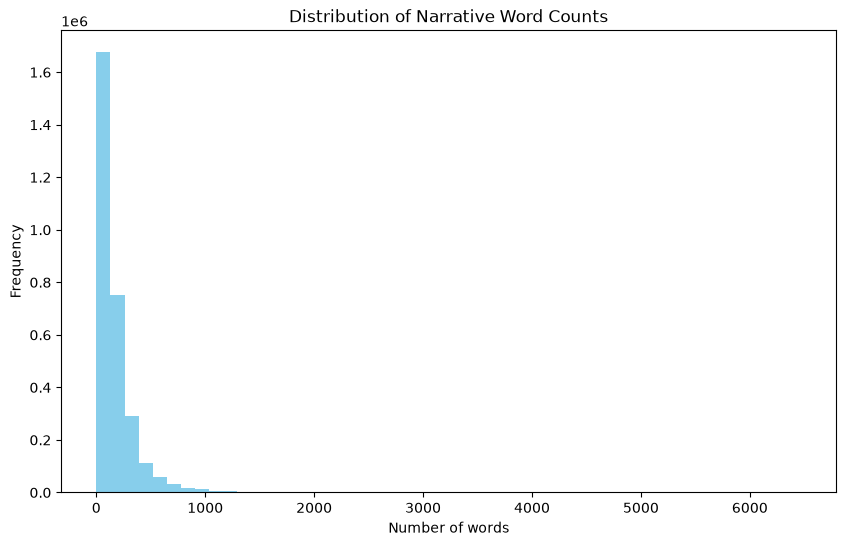

In [5]:
# Ensure 'Consumer complaint narrative' exists
df['word_count'] = df['Consumer complaint narrative'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(df[df['word_count'] > 0]['word_count'], bins=50, color='skyblue')
plt.title("Distribution of Narrative Word Counts")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

Filtering

In [6]:
# Filter for the 4 products
target_products = ['Credit card', 'Personal loan', 'Savings account', 'Money transfer']
df_filtered = df[df['Product'].isin(target_products)].copy()

# Remove empty narratives
df_filtered = df_filtered.dropna(subset=['Consumer complaint narrative'])

Cleaning

In [7]:
# Lowercase and boilerplate removal
df_filtered['Consumer complaint narrative'] = df_filtered['Consumer complaint narrative'].str.lower()
# Simple boilerplate removal
df_filtered['Consumer complaint narrative'] = df_filtered['Consumer complaint narrative'].str.replace("i am writing to file a complaint", "", regex=False)

# Save the cleaned file
df_filtered.to_csv('../data/filtered_complaints.csv', index=False)